# Notebook 1 — Green / Climate Alpha Strategy (initial research direction)

**MFE 230GA Active Asset Management — Final Project, Group 4**
Hashim Almodamagha, Aditya Aryan, Jack Duncan, Charishma Takkallapalli, Cristhian Ruiz Cardozo

This notebook is the analytical record of our **first** research direction and of why we did **not**
implement it. The final strategy is in `02_Charisma_Final_Strategy.ipynb`; the full discussion is in
`MFE230GA_Final_Project.pdf` (Section 2 and Appendix A).

The outputs shown are from the executed, validated run. Cells marked *imported verified evidence* load
results computed in the team's research extension (`230GA-Final-Project-hashim-research-extension`),
where each number was produced twice by independent code; they are not rerun here.

## 1. Research question

Can differences in industry carbon intensity, timed by climate-transition attention, produce a
tradable, factor-neutral return across the Fama–French 49 industries?

The idea came from Homework 1, where we compared high- and low-emission industries and used an AI
assistant to propose strategies. The mechanism: if investors re-price transition risk when climate
concern rises unexpectedly (Pástor, Stambaugh and Taylor, 2021, 2022), high-emission ("Brown")
industries should underperform after spikes in climate attention, even without a permanent green premium.
**Falsification:** if a holdout never used in design shows no such profit, the thesis is wrong.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

import sys
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()   # final_submission_organized/
sys.path.insert(0, str(REPO / "supporting" / "code" / "green"))              # climate_lib (team pipeline)

from climate_lib.common import load_team, corrected_macro
from climate_lib.team_pipeline import (run_pipeline, team_controls, TEAM_GREEN, TEAM_BROWN,
                                       newey_west_regression)

DATA, FIG, TAB = REPO / "data" / "green", REPO / "figures", REPO / "tables"
FIG.mkdir(exist_ok=True); TAB.mkdir(exist_ok=True)
pd.set_option("display.width", 200)
NUM: dict = {}

## 2. Data

Files in `data/green/` (the team's inputs, unchanged): Ken French 49 value-weighted industry returns and
FF3 factors (July 1926–July 2026), one cross-section of emissions intensity for 41 of the 49 industries
(the Homework 1 course file), and macro series including the "climate attention" column. We add FRED series
EMVENRGYENVREG to check what that column is, the team's committed results table, and the imported verified
extension results.

In [2]:
T = load_team()
print("industries:", T["industries"].index.min().date(), "to", T["industries"].index.max().date())
print("emissions file covers", T["emissions"].shape[0], "industries")
print("Green leg:", TEAM_GREEN); print("Brown leg:", TEAM_BROWN)

industries: 1926-07-31 to 2026-07-31
emissions file covers 41 industries
Green leg: ['Fun', 'RlEst', 'Drugs', 'Telcm', 'Fin']
Brown leg: ['Util', 'Ships', 'Aero', 'Steel', 'BldMt']


## 3. Green/Brown signal

* **Legs:** Green = five lowest-intensity industries, Brown = five highest, equal-weighted.
* **Hedge:** rolling 60-month FF3 regression of the Brown leg; betas estimated through month t hedge month t+1.
  The traded object is the hedged Brown return.
* **Signal:** 60-month z-score of log(1 + attention). When it crosses its past-only 80th percentile, the rule
  shorts the hedged Brown leg for 3 or 6 months ("Original"; "Pure" first removes the part of attention
  explained by lagged macro data). Size targets 5% residual volatility, capped at 1.
* **Costs:** 10 bp on the leg, 5 bp on the market overlay, 25 bp on SMB/HML overlays, per unit turnover.

### 3.1 What is the "attention" series?

In [3]:
fred = pd.read_csv(DATA / "fred_EMVENRGYENVREG.csv", parse_dates=["observation_date"])
fred.index = fred.observation_date + pd.offsets.MonthEnd(0)
att = T["macro"]["attention"].dropna()
common = att.index.intersection(fred.index)
same = np.isclose(att.loc[common].values, fred.loc[common, "EMVENRGYENVREG"].values, atol=1e-9)
NUM["identity_months"] = int(len(common)); NUM["identity_equal"] = int(same.sum())
pre = att[(att.index < "2021-10-01")]; post = att[att.index >= "2021-10-01"]
NUM["zeros_pre"] = f"{int((pre == 0).sum())}/{len(pre)}"; NUM["zeros_post"] = f"{int((post == 0).sum())}/{len(post)}"
print(f"Team attention equals FRED EMVENRGYENVREG in {same.sum()} of {len(common)} months")
print("exact zeros before 2021-10:", NUM["zeros_pre"], " from 2021-10:", NUM["zeros_post"])

Team attention equals FRED EMVENRGYENVREG in 500 of 500 months
exact zeros before 2021-10: 12/441  from 2021-10: 39/59


**Interpretation.** EMVENRGYENVREG is the Baker, Bloom, Davis and Kost (2019) Equity Market Volatility tracker
for energy and environmental regulation: a count of newspaper articles about **stock-market volatility** that
mention that topic. It is not a climate-concern index, and since late 2021 it is mostly exact zeros. We did not
know this when we designed the rule.

## 4. Baseline strategy: the team's timing rules as first implemented

`run_pipeline()` with default arguments reproduces the team's committed comparison table exactly (checked below).
Design window: 2010-01 to 2022-07. Holdout, never used in design: 2022-08 to 2026-07.

In [5]:
team = run_pipeline(bootstrap_reps=0, macro_states=False, paired=False, extras=False)
ref = pd.read_csv(DATA / "team_comparison_table_committed.csv") if (DATA / "team_comparison_table_committed.csv").exists() else None
if ref is not None:
    diff = (team["comparison_table"].set_index("strategy")["ann_return_full"] - ref.set_index("strategy")["ann_return_full"]).abs().max()
    print("max |reproduced - committed| annual return:", diff); assert diff < 1e-10
STRATS = {"Original | Short Brown hold 3m": "Original 3m", "Original | Short Brown hold 6m": "Original 6m",
          "Pure | Short Brown hold 3m": "Pure 3m", "Pure | Short Brown hold 6m": "Pure 6m",
          "Continuous | raw attention": "Continuous raw", "Benchmark | Always-short Brown": "Always-short Brown"}
pt_team = team["period_table"]
v = pt_team[pt_team.strategy.isin(STRATS) & pt_team.period.isin(["Validation 2010-Jul2022", "Holdout Aug2022-Jul2026"])]
display(v.assign(strategy=v.strategy.map(STRATS))[["strategy", "period", "ann_net", "sharpe_net", "alpha_ann", "alpha_t_hac6"]].round(4))
for _, r in v.iterrows():
    k = f"team_{STRATS[r.strategy]}_{r.period.split()[0]}"
    NUM[k + "_net"] = float(r.ann_net); NUM[k + "_alpha"] = float(r.alpha_ann); NUM[k + "_t"] = float(r.alpha_t_hac6)
hold = v[(v.period.str.startswith("Holdout")) & v.strategy.str.contains("hold")]
NUM["team_holdout_discrete_net_min"] = float(hold.ann_net.min()); NUM["team_holdout_discrete_net_max"] = float(hold.ann_net.max())

max |reproduced - committed| annual return: 1.0755285551056204e-16


,strategy,period,ann_net,sharpe_net,alpha_ann,alpha_t_hac6
1,Original 3m,Validation 2010-Jul2022,0.0131,0.4124,0.0133,1.4683
2,Original 3m,Holdout Aug2022-Jul2026,-0.0382,-1.1532,-0.0403,-2.1873
9,Pure 3m,Validation 2010-Jul2022,0.0141,0.4382,0.0144,1.4957
10,Pure 3m,Holdout Aug2022-Jul2026,-0.0217,-0.9322,-0.0221,-1.9322
17,Original 6m,Validation 2010-Jul2022,0.0245,0.5883,0.0225,2.2304
18,Original 6m,Holdout Aug2022-Jul2026,-0.0214,-0.4916,-0.0228,-1.6573
25,Pure 6m,Validation 2010-Jul2022,0.0259,0.5995,0.0251,2.4574
26,Pure 6m,Holdout Aug2022-Jul2026,-0.0304,-0.7393,-0.0271,-1.9436
33,Continuous raw,Validation 2010-Jul2022,0.0066,0.4472,0.0053,1.5989
34,Continuous raw,Holdout Aug2022-Jul2026,-0.0065,-0.5986,-0.0076,-1.9844


**Interpretation.** In the design window the 6-month rules earned about 2.5% a year net with FF3 alpha t above 2.
In the holdout every discrete rule lost 2.1% to 3.8% a year.

## 5. Key alternative implementations: the corrected baseline

Two input problems were fixed before any further test: (1) attention and the purification controls are lagged one
month, because month-t attention may not be published by the end of month t; (2) the October 2025 CPI print, never
published, is interpolated. The table also shows the continuous version of the rule (position scales smoothly with the
signal) and the untimed always-short benchmark. No verdict changes.

In [6]:
m3 = corrected_macro()
corr = run_pipeline(macro=m3, attention=m3["attention"].shift(1), controls=team_controls(m3).shift(1),
                    bootstrap_reps=0, macro_states=False, paired=False, extras=False)
pt = corr["period_table"]
WIN = {"Validation 2010-Jul2022": "Validation 2010-01 to 2022-07", "Holdout Aug2022-Jul2026": "Holdout 2022-08 to 2026-07",
       "COVID 2020-2021": "COVID 2020-01 to 2021-12", "Recent 18m (Feb2025-Jul2026)": "Last 18m 2025-02 to 2026-07",
       "Recent 12m (Aug2025-Jul2026)": "Last 12m 2025-08 to 2026-07", "Full 2010-Jul2026": "Post-2010 2010-01 to 2026-07"}
show = ["Original | Short Brown hold 3m", "Original | Short Brown hold 6m", "Continuous | raw attention", "Benchmark | Always-short Brown"]
tp = pt[pt.strategy.isin(show) & pt.period.isin(WIN)].copy()
tp["Strategy"] = tp.strategy.map(STRATS); tp["Window"] = tp.period.map(WIN)
tp = tp[["Window", "Strategy", "n_months", "active_months", "ann_net", "alpha_ann", "alpha_t_hac6"]]
tp.to_csv(TAB / "C2_time_patterns.csv", index=False)
display(tp.round(4))
for _, r in tp.iterrows():
    k = f"corr_{r.Strategy}_{r.Window.split()[0]}"
    NUM[k + "_net"] = float(r.ann_net); NUM[k + "_alpha"] = float(r.alpha_ann); NUM[k + "_t"] = float(r.alpha_t_hac6)

,Window,Strategy,n_months,active_months,ann_net,alpha_ann,alpha_t_hac6
0,Post-2010 2010-01 to 2026-07,Original 3m,199,96,0.0073,0.0079,1.0364
1,Validation 2010-01 to 2022-07,Original 3m,151,74,0.0178,0.0162,1.9722
2,Holdout 2022-08 to 2026-07,Original 3m,48,22,-0.0257,-0.0216,-1.8989
4,COVID 2020-01 to 2021-12,Original 3m,24,17,0.0804,0.0638,3.6202
6,Last 12m 2025-08 to 2026-07,Original 3m,12,6,-0.0521,0.0120,0.2958
7,Last 18m 2025-02 to 2026-07,Original 3m,18,10,-0.0451,-0.0405,-1.5517
16,Post-2010 2010-01 to 2026-07,Original 6m,199,141,0.0119,0.0121,1.3620
17,Validation 2010-01 to 2022-07,Original 6m,151,104,0.0216,0.0209,2.1838
18,Holdout 2022-08 to 2026-07,Original 6m,48,37,-0.0184,-0.0197,-1.3024
20,COVID 2020-01 to 2021-12,Original 6m,24,24,0.0595,0.0399,1.7870


## 6. Out-of-sample and regime evidence

### 6.1 Does COVID certify the timing? Compare the rule with an untimed short of the same leg.

The always-short position uses the same leg, hedge and volatility target but ignores the signal. The paired alpha is
the FF3 alpha of (rule return − always-short return).

In [7]:
fac = T["ff3"][["Mkt-RF", "SMB", "HML"]]
paired = []
for s in ["Original | Short Brown hold 3m", "Original | Short Brown hold 6m"]:
    for lab, (a, b) in {"COVID": ("2020-01-31", "2021-12-31"), "Holdout": ("2022-08-31", "2026-07-31"),
                        "Validation": ("2010-01-31", "2022-07-31")}.items():
        dlt = (corr["strategies"][s]["net_return"] - corr["strategies"]["Benchmark | Always-short Brown"]["net_return"]).loc[a:b]
        d = pd.concat([dlt.rename("d"), fac], axis=1, sort=True).dropna()
        m = sm.OLS(d.d, sm.add_constant(d[["Mkt-RF", "SMB", "HML"]])).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
        paired.append({"Strategy": STRATS[s], "Window": lab, "n": len(d), "paired_alpha": 12 * m.params["const"], "t": m.tvalues["const"]})
        NUM[f"paired_{STRATS[s]}_{lab}_alpha"] = float(12 * m.params["const"]); NUM[f"paired_{STRATS[s]}_{lab}_t"] = float(m.tvalues["const"])
paired = pd.DataFrame(paired); display(paired.round(4))

,Strategy,Window,n,paired_alpha,t
0,Original 3m,COVID,24,0.0184,0.8714
1,Original 3m,Holdout,48,-0.0044,-0.3329
2,Original 3m,Validation,151,0.0023,0.2285
3,Original 6m,COVID,24,-0.0055,-0.6970
4,Original 6m,Holdout,48,-0.0025,-0.2394
5,Original 6m,Validation,151,0.0070,1.0033


**Interpretation.** In COVID the rule's edge over simply being short the same leg is 1.84% a year (t = 0.87): the gain is mostly exposure, not timing.

### 6.2 Does the signal still point the right way out of sample?

In [8]:
ic = corr["ic_table"]
display(ic.round(3))
for _, r in ic.iterrows():
    NUM[f"ic_{r.signal}_{r.period.split()[0]}"] = float(r.IC); NUM[f"ic_t_{r.signal}_{r.period.split()[0]}"] = float(r.t_hac6)

,signal,period,IC,t_hac6,n
0,Raw attention,Full 2010-Jul2026,-0.012,-0.156,198
1,Raw attention,Validation 2010-Jul2022,-0.029,-0.279,151
2,Raw attention,Holdout Aug2022-Jul2026,0.031,0.356,47
3,Purified attention,Full 2010-Jul2026,-0.026,-0.312,198
4,Purified attention,Validation 2010-Jul2022,-0.050,-0.451,151
5,Purified attention,Holdout Aug2022-Jul2026,0.035,0.419,47
6,Continuous weight (raw),Full 2010-Jul2026,-0.089,-1.457,198
7,Continuous weight (raw),Validation 2010-Jul2022,-0.150,-2.192,151
8,Continuous weight (raw),Holdout Aug2022-Jul2026,0.064,0.624,47
9,Continuous weight (pure),Full 2010-Jul2026,-0.106,-1.654,198


**Interpretation.** The continuous signal's IC is −0.15 (t = −2.19) in design and +0.06 in the holdout: the relationship reversed out of sample.

### 6.3 Figure: timed rule vs. untimed always-short position

In [9]:
INK, INK2, GRID, BLUE, ORANGE = "#0b0b0b", "#52514e", "#e4e3df", "#2a78d6", "#eb6834"
plt.rcParams.update({"font.size": 9, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": GRID, "grid.linewidth": 0.6, "legend.frameon": False, "axes.edgecolor": INK2,
                     "xtick.color": INK2, "ytick.color": INK2})
fig, ax = plt.subplots(figsize=(7.0, 2.6))
for s, col, lab in [("Original | Short Brown hold 6m", BLUE, "Original 6m (timed by attention)"),
                    ("Benchmark | Always-short Brown", ORANGE, "Always-short Brown (no signal)")]:
    r = corr["strategies"][s]["net_return"].loc["2010-01-31":"2026-07-31"]
    c = (1 + r.fillna(0)).cumprod() - 1
    ax.plot(c.index, 100 * c.values, color=col, lw=1.6, label=lab)
ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2021-12-31"), color=GRID, alpha=0.9, lw=0)
ax.axvspan(pd.Timestamp("2022-08-01"), pd.Timestamp("2026-07-31"), color="#f3d9cf", alpha=0.7, lw=0)
ax.text(pd.Timestamp("2020-02-01"), ax.get_ylim()[0] + 1, "COVID", fontsize=8, color=INK2)
ax.text(pd.Timestamp("2022-09-01"), ax.get_ylim()[0] + 1, "Holdout (untouched in design)", fontsize=8, color=INK2)
ax.axhline(0, color=INK2, lw=0.8)
ax.set_ylabel("Cumulative net return (%)")
ax.set_title("Corrected baseline, net of costs, Jan 2010-Jul 2026", fontsize=9, loc="left")
ax.legend(loc="upper left", fontsize=8)
ax.xaxis.set_major_locator(mdates.YearLocator(2)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout(); fig.savefig(FIG / "C1_timed_vs_always_short.pdf"); fig.savefig(FIG / "C1_timed_vs_always_short.png", dpi=200)
plt.close(fig)

**Figure C1. Cumulative net return, corrected baseline, January 2010–July 2026. Grey: COVID; shaded: holdout.**

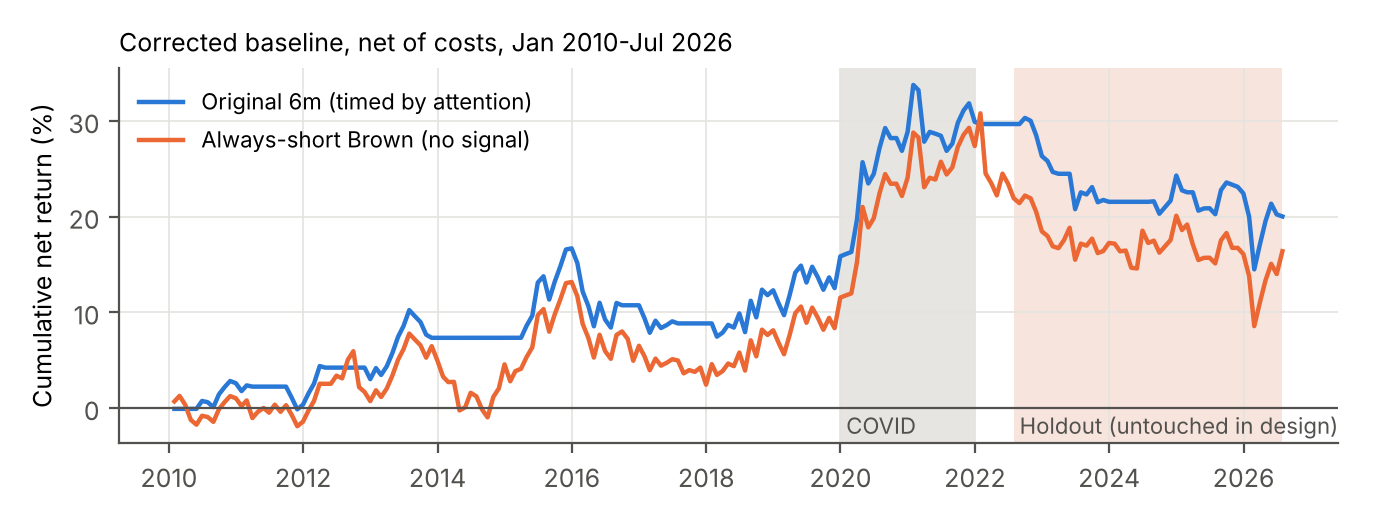

## 7. Factor interpretation and costs

### 7.1 The raw Green-minus-Brown spread is a value bet

In [4]:
ind, ff3 = T["industries"], T["ff3"]
gb = ind[TEAM_GREEN].mean(axis=1) - ind[TEAM_BROWN].mean(axis=1)
rows = []
for lab, (a, b) in {"1970-2026": ("1970-01-31", "2026-07-31"), "2010-2026": ("2010-01-31", "2026-07-31")}.items():
    d = pd.concat([gb.rename("gb"), ff3[["Mkt-RF", "SMB", "HML"]]], axis=1).loc[a:b].dropna()
    m = sm.OLS(d.gb, sm.add_constant(d[["Mkt-RF", "SMB", "HML"]])).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    rows.append({"window": lab, "n": len(d), "mean_ann": 12 * d.gb.mean(), "alpha_ann": 12 * m.params["const"],
                 "alpha_t": m.tvalues["const"], "HML": m.params["HML"], "HML_t": m.tvalues["HML"]})
    NUM[f"gb_hml_{lab}"] = float(m.params["HML"]); NUM[f"gb_hml_t_{lab}"] = float(m.tvalues["HML"])
    NUM[f"gb_alpha_{lab}"] = float(12 * m.params["const"]); NUM[f"gb_alpha_t_{lab}"] = float(m.tvalues["const"])
spread = pd.DataFrame(rows); display(spread.round(3))

,window,n,mean_ann,alpha_ann,alpha_t,HML,HML_t
0,1970-2026,679,-0.005,0.005,0.407,-0.233,-4.626
1,2010-2026,199,-0.018,-0.011,-0.489,-0.298,-5.744


**Interpretation.** The raw spread loads −0.23 on HML over 1970–2026 (t = −4.63) and −0.30 since 2010 (t = −5.74), with no significant alpha.

### 7.2 Are costs the reason? Turnover, cost drag and gross holdout alpha

In [10]:
from climate_lib.team_pipeline import turnover_and_cost_drag
crow = []
for s in ["Original | Short Brown hold 3m", "Original | Short Brown hold 6m", "Pure | Short Brown hold 3m", "Pure | Short Brown hold 6m"]:
    df = corr["strategies"][s]
    tc = turnover_and_cost_drag(df, "2010-01-31", "2026-07-31")
    g = pd.concat([df["gross_return"].loc["2022-08-31":"2026-07-31"].rename("g"), fac], axis=1, sort=True).dropna()
    m = sm.OLS(g.g, sm.add_constant(g[["Mkt-RF", "SMB", "HML"]])).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    crow.append({"Strategy": STRATS[s], "turnover_x_per_year": tc["annual_turnover_x"], "cost_drag_ann": tc["ann_cost_drag"],
                 "holdout_gross_alpha": 12 * m.params["const"], "holdout_gross_t": m.tvalues["const"]})
cost_tab = pd.DataFrame(crow); display(cost_tab.round(4))
NUM["turnover_min"] = float(cost_tab.turnover_x_per_year.min()); NUM["turnover_max"] = float(cost_tab.turnover_x_per_year.max())
NUM["costdrag_max"] = float(cost_tab.cost_drag_ann.max()); NUM["holdout_gross_alpha_max"] = float(cost_tab.holdout_gross_alpha.max())

,Strategy,turnover_x_per_year,cost_drag_ann,holdout_gross_alpha,holdout_gross_t
0,Original 3m,4.7953,0.0053,-0.0167,-1.4770
1,Original 6m,2.7233,0.0032,-0.0151,-0.9962
2,Pure 3m,5.2851,0.0059,-0.0167,-1.4770
3,Pure 6m,2.8183,0.0033,-0.0151,-0.9962


**Interpretation.** Costs take at most about 0.6 percentage points a year, but holdout alphas are negative before costs (at best −1.5%). Costs are not why the strategy fails.

## 8. Robustness evidence already obtained (imported verified evidence)

The research extension ran further modules whose inputs (EPA supply-chain factors, Census crosswalks, MCCC and CPU
climate-concern indices, pre-1970 data) are not part of this package: the signal audit (M1, M1b), the frozen 1994–2009
test (M8), the EPA emissions rebuild (M4), carbon-aware industry momentum (M5) and the project-wide multiple-testing
ledger (M7). Each headline number was computed twice by independent code. `supporting/code/green/build_verified_evidence.py`
copied the numbers we quote, with source file and row, into `data/green/verified_extension_results.csv`. **These results
are loaded, not recomputed.**

In [11]:
ev = pd.read_csv(DATA / "verified_extension_results.csv")
display(ev[["name", "value", "source_file"]])
E = ev.set_index("name")["value"]

,name,value,source_file
0,M1_identity_overlap_months,500,outputs/tables/M1_signal_audit_key_numbers.csv
1,M1_identity_months_not_equal,0,outputs/tables/M1_signal_audit_key_numbers.csv
2,M1_zeros_pre_2021-10,12/441,outputs/tables/M1_signal_audit_key_numbers.csv
3,M1_zeros_post_2021-10,39/59,outputs/tables/M1_signal_audit_key_numbers.csv
4,M1_R2_teamz_on_z_VIX_and_z_EMV_overall_full,0.16863600008403268,outputs/tables/M1_signal_audit_key_numbers.csv
5,M1_corr_z_MCCC_teamsignal,-0.000350387614526,outputs/tables/M1_signal_audit_measure_correla...
6,M1_corr_z_CPU_teamsignal,0.122784557316318,outputs/tables/M1_signal_audit_measure_correla...
7,M1b_climate_index_validation_alphas_total,12,outputs/tables/M1b_alt_signals_primary.csv
8,M1b_climate_index_validation_alphas_t_ge_1.96,0,outputs/tables/M1b_alt_signals_primary.csv
9,M8_primary_timing_alpha_statistic,"alpha -0.0018/yr, t -0.27",outputs/tables/M8_passbar.csv


### 8.1 Summary of the experiments that changed our view

In [12]:
def f(x, d=2):
    return f"{float(x):.{d}f}"

def pc(x, d=2):
    return f"{100 * float(x):.{d}f}%"

_m8 = str(E["M8_primary_timing_alpha_statistic"]).replace(",", "").split()
m8a, m8t = 100 * float(_m8[1].replace("/yr", "")), float(_m8[3])
NUM["m8_alpha_pct"] = m8a; NUM["m8_t"] = m8t
c = lambda s, w, k: NUM[f"corr_{s}_{w}_{k}"]  # noqa: E731
exp = pd.DataFrame([
    {"Experiment": "Team rules as first built (validation 2010-2022 vs. holdout 2022-2026)",
     "Looked promising": f"Original 6m validation net {pc(NUM['team_Original 6m_Validation_net'])}, FF3 alpha t = {f(NUM['team_Original 6m_Validation_t'])}",
     "What happened": f"every discrete rule lost {pc(-NUM['team_holdout_discrete_net_max'],1)} to {pc(-NUM['team_holdout_discrete_net_min'],1)} a year in the holdout"},
    {"Experiment": "What the attention series measures",
     "Looked promising": "label: climate-transition attention",
     "What happened": f"equals FRED EMV energy/environmental-regulation volatility tracker in {NUM['identity_equal']}/{NUM['identity_months']} months; corr. with MCCC climate concern {f(E['M1_corr_z_MCCC_teamsignal'],4)}; {E['M1b_climate_index_validation_alphas_t_ge_1.96']} of {E['M1b_climate_index_validation_alphas_total']} climate-index validation alphas with t >= 1.96"},
    {"Experiment": "Timing vs. simply being short Brown (COVID)",
     "Looked promising": f"Original 3m COVID FF3 alpha {pc(c('Original 3m','COVID','alpha'))} (t = {f(c('Original 3m','COVID','t'))})",
     "What happened": f"always-short alpha {pc(c('Always-short Brown','COVID','alpha'))} (t = {f(c('Always-short Brown','COVID','t'))}); paired edge {pc(NUM['paired_Original 3m_COVID_alpha'])} (t = {f(NUM['paired_Original 3m_COVID_t'])})"},
    {"Experiment": "Frozen pre-registered rule, 1994-2009",
     "Looked promising": "a cleaner signal (regulation share of volatility news), frozen before testing",
     "What happened": f"timing alpha {m8a:+.2f}% a year (t = {m8t:.2f}); calendar-shuffle p = {f(E['M8_primary_shuffle_p'])}; fails 3 of 4 bars"},
    {"Experiment": "Alternatives on the same data",
     "Looked promising": f"EPA supply-chain ranking: post-2010 FF5+UMD alpha {pc(E['M4_epa_gb_post2010_ff5umd_alpha'],1)}; carbon-aware industry momentum",
     "What happened": f"EPA alpha t = {f(E['M4_epa_gb_post2010_ff5umd_t'])}; momentum book FF5+UMD alpha t = {f(E['M5_ew_momentum_full_1970_ff5umd_t_alpha'])} with UMD beta {f(E['M5_ew_momentum_full_1970_ff5umd_b_UMD'])}"},
    {"Experiment": "Multiple testing across the whole program",
     "Looked promising": "several individual t > 2 results",
     "What happened": f"{E['M7_family_P_tests']} module primary alphas: smallest Holm-adjusted p = {E['M7_family_P_holm_min_p']}"},
])
exp.to_csv(TAB / "C1_experiments.csv", index=False)
display(exp)

,Experiment,Looked promising,What happened
0,Team rules as first built (validation 2010-202...,"Original 6m validation net 2.45%, FF3 alpha t ...",every discrete rule lost 2.1% to 3.8% a year i...
1,What the attention series measures,label: climate-transition attention,equals FRED EMV energy/environmental-regulatio...
2,Timing vs. simply being short Brown (COVID),Original 3m COVID FF3 alpha 6.38% (t = 3.62),always-short alpha 4.54% (t = 1.96); paired ed...
3,"Frozen pre-registered rule, 1994-2009",a cleaner signal (regulation share of volatili...,timing alpha -0.18% a year (t = -0.27); calend...
4,Alternatives on the same data,EPA supply-chain ranking: post-2010 FF5+UMD al...,EPA alpha t = 1.52; momentum book FF5+UMD alph...
5,Multiple testing across the whole program,several individual t > 2 results,73 module primary alphas: smallest Holm-adjust...


## 9. Decision: do not implement

In order of importance:

1. **Out-of-sample failure.** The untouched holdout lost money for every rule, the frozen 1994–2009 test failed
   (timing alpha −0.18% a year, t = −0.27), and the signal's IC changed sign in the holdout.
2. **The signal is mislabeled.** It is a stock-market-volatility news count, uncorrelated with climate-concern
   measures; climate indices fed through the same rules earn nothing (0 of 12 validation alphas with t ≥ 1.96).
3. **Timing cannot be separated from exposure.** The best window (COVID) is mostly earned by an untimed short of the
   same Brown leg.
4. **Factor exposure and data limits.** The raw spread is a short-value bet; the emissions file is one undated snapshot
   applied backward (look-ahead in leg membership), and an EPA rebuild moves two of the five Brown industries to mid-table.
5. **Multiple testing.** Across 73 module primary alphas the smallest Holm-adjusted p is 1.00.

Costs are not the reason: gross holdout alphas were already negative.

**The economic idea was plausible, but the evidence was not stable or clean enough to support implementation.**

## 10. Why we pivoted

We did not search for another specification to rescue the strategy. One lesson carried over: every alternative that
looked profitable was a known factor in disguise, and an equal-weight industry momentum book was essentially UMD
(beta ≈ 1). That led to the sharper question tested in `02_Charisma_Final_Strategy.ipynb`: **do analyst EPS revisions
contain information beyond industry momentum, after FF5 and UMD?**

---
*Appendix: export of the tables used in the final report (writes to `tables/`).*

In [13]:
import re


def tex_escape(s):
    s = re.sub(r"(?<![A-Za-z0-9])-(?=\d)", "$-$", str(s))
    return s.replace("%", r"\%").replace("&", r"\&").replace(">=", r"$\geq$").replace("_", r"\_")

lines = [r"\begin{tabular}{p{0.24\linewidth}p{0.31\linewidth}p{0.37\linewidth}}", r"\toprule",
         r"Experiment & What looked promising & What happened \\", r"\midrule"]
for _, r in exp.iterrows():
    lines.append(f"{tex_escape(r.Experiment)} & {tex_escape(r['Looked promising'])} & {tex_escape(r['What happened'])} \\\\")
lines += [r"\bottomrule", r"\end{tabular}"]
(TAB / "C1_experiments.tex").write_text("\n".join(lines) + "\n")

order = ["Validation 2010-01 to 2022-07", "Holdout 2022-08 to 2026-07", "COVID 2020-01 to 2021-12", "Last 18m 2025-02 to 2026-07"]
cols = ["Original 3m", "Original 6m", "Always-short Brown"]
lines = [r"\begin{tabular}{lrrr}", r"\toprule", "Window & " + " & ".join(cols) + r" \\", r"\midrule"]
for w in order:
    cells = []
    for s in cols:
        r = tp[(tp.Window == w) & (tp.Strategy == s)].iloc[0]
        cells.append(f"{100*r.ann_net:.2f} / {100*r.alpha_ann:.2f} ({r.alpha_t_hac6:.2f})".replace("-", "$-$"))
    n = int(tp[tp.Window == w].n_months.iloc[0])
    name, span = w.rsplit(" ", 3)[0], " ".join(w.rsplit(" ", 3)[1:])
    lines.append(f"{name} ({span}), $n$={n} & " + " & ".join(cells) + r" \\")
lines += [r"\bottomrule", r"\end{tabular}"]
(TAB / "C2_time_patterns.tex").write_text("\n".join(lines).replace("Last 18m (", "Last 18m (").replace(" to ", "--") + "\n")
(TAB / "climate_numbers.json").write_text(json.dumps(NUM, indent=1, default=str))
print(sorted(p.name for p in TAB.iterdir())); print(sorted(p.name for p in FIG.iterdir()))

['C1_experiments.csv', 'C1_experiments.tex', 'C2_time_patterns.csv', 'C2_time_patterns.tex', 'climate_numbers.json']
['C1_timed_vs_always_short.pdf', 'C1_timed_vs_always_short.png']
